# Refactor of H5 Processing

In [163]:
import sys, logging, importlib

# Ensure your scripts dir is importable
sys.path.append("/global/cfs/cdirs/m4958/usr/danieltm/ColliderML/software/colliderml_dev/scripts/postprocessing")

# 1) Set global logging and quiet noisy libs
logging.basicConfig(
    level=logging.DEBUG,
    format="%(asctime)s - %(levelname)s - %(name)s - %(message)s",
    force=True,
)
for noisy in ["uproot", "fsspec", "s3fs", "urllib3", "numexpr", "matplotlib"]:
    logging.getLogger(noisy).setLevel(logging.WARNING)

# 2) Turn up only your modules to DEBUG (others inherit WARNING from above)
for name in [
    "convert_all",
    "convert_particles",
    "convert_digihits",
    "convert_tracks",
    "utils",
    "utils.track_utils",
    "utils.driver",
    "utils.path_utils",
]:
    logging.getLogger(name).setLevel(logging.DEBUG)

In [164]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import uproot
import sys
import seaborn as sns
from tqdm import tqdm
import networkx as nx
import matplotlib.cm as cm
import h5py
import logging
import awkward as ak
import uproot

import atlasify as atl
from particle import Particle
atl.ATLAS = "ColliderML"

sys.path.append("/global/cfs/cdirs/m4958/usr/danieltm/ColliderML/software/OtherLibraries/pyedm4hep")
from pyedm4hep import EDM4hepEvent, EDM4hepEventBatch

from pathlib import Path
import logging

# Reuse postprocessing helpers
sys.path.append("/global/cfs/cdirs/m4958/usr/danieltm/ColliderML/software/colliderml_dev/scripts/postprocessing")
from convert_particles import build_particles_df_with_parents_and_vertex, write_particles_with_selection
from convert_digihits import process_event_for_digihits, write_digihits_with_selection
from utils.path_utils import get_run_paths, make_dir
from utils.track_utils import load_root_file, load_track_summary, create_particle_barcode_map

from convert_all import convert_all


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## EDM4Hep Event Testing

In [2]:
edm_input_file = "/pscratch/sd/d/danieltm/ColliderML/simulation/full_pileup_pilot/ttbar/v2/runs/0/edm4hep.root"
event = EDM4hepEvent(edm_input_file, event_index=0)

Augmenting particles
Ready with tracker hits Index(['cellID', 'time', 'x', 'y', 'z', 'particle_id', 'detector', 'r', 'R',
       'phi', 'theta', 'eta'],
      dtype='object')
Augmenting particle hit counts with tracker hits


In [3]:
print(f"""
Number of calo hits: {len(event.get_calo_hits_df())}
Number of particles: {len(event.get_particles_df())}
Number of tracker hits: {len(event.get_tracker_hits_df())}
""")


Number of calo hits: 1243953
Number of particles: 880327
Number of tracker hits: 240622



## EDM4Hep Event Batch Testing

In [ ]:
edm_input_file = "/pscratch/sd/d/danieltm/ColliderML/simulation/full_pileup_pilot/ttbar/v2/runs/0/edm4hep.root"
event = EDM4hepEvent(edm_input_file, event_index=0)

Augmenting particles
Ready with tracker hits Index(['cellID', 'time', 'x', 'y', 'z', 'particle_id', 'detector', 'r', 'R',
       'phi', 'theta', 'eta'],
      dtype='object')
Augmenting particle hit counts with tracker hits


In [ ]:
print(f"""
Number of calo hits: {len(event.get_calo_hits_df())}
Number of particles: {len(event.get_particles_df())}
Number of tracker hits: {len(event.get_tracker_hits_df())}
""")


Number of calo hits: 1243953
Number of particles: 880327
Number of tracker hits: 240622



## Combined multi-output conversion (single open per run)

This workflow opens each `edm4hep.root` once per run and produces multiple H5 outputs (truth/particles and reco/tracker_hits) in one pass, reusing preloaded DataFrames to avoid repeated IO.


In [3]:
# Configurable column selection for H5 outputs
particles_columns_keep = [
    "particle_id", "pdg_id", "mass", "energy", "charge",
    "vx", "vy", "vz", "time", "px", "py", "pz",
    "num_tracker_hits", "num_calo_hits", "vertex_primary", "parent_id",
]
digihits_columns_keep = [
    "x", "y", "z", "time", "particle_id",
    "true_x", "true_y", "true_z",
    "volume_id", "layer_id", "surface_id",
    "cell_id", "detector", "event_id",
]

tracks_columns_keep = [
    "event_id", "majority_particle_id", "d0", "z0", "phi", "theta", "qop"
]


In [4]:
# Config for this combined test (aligns with your production YAMLs)
campaign = "full_pileup_pilot"
dataset = "ttbar"
version = "v2"

base_root = Path("/pscratch/sd/d/danieltm/ColliderML/simulation")
output_base_dir = Path("./h5_testing/v2")  # unified root like scripts

# logging.basicConfig(
#     level=logging.DEBUG,  # show DEBUG and above
#     format="%(asctime)s - %(levelname)s - %(name)s - %(message)s",
#     handlers=[logging.StreamHandler(sys.stdout)],
#     force=True,  # override prior configs in this kernel
# )

config = {
    "chunk_size": 128,
    "run_size": 128,
    "max_chunks": 1,
    "campaign": "full_pileup_pilot",
    "dataset": "ttbar",
    "version": "v2",
    "common": {
        "output_base_dir": base_root,
    },
    "objects": ["tracker_hits", "particles", "tracks"],
    "particles_columns_keep": particles_columns_keep,
    "digihits_columns_keep": digihits_columns_keep,
    "tracks_columns_keep": tracks_columns_keep,
    "min_tracker_hits": 1,
    "h5_output_dir": output_base_dir,
}


## Step-by-step Conversion

Roadmap:

- Convert a small set of edm4hep events to h5

In [165]:
# Config for this combined test (aligns with your production YAMLs)
campaign = "full_pileup_pilot"
dataset = "ttbar"
version = "v2"

base_root = Path("/pscratch/sd/d/danieltm/ColliderML/simulation")
output_base_dir = Path("./h5_testing/v4")  # unified root like scripts

# logging.basicConfig(
#     level=logging.INFO,  # show DEBUG and above
#     format="%(asctime)s - %(levelname)s - %(name)s - %(message)s",
#     handlers=[logging.StreamHandler(sys.stdout)],
#     force=True,  # override prior configs in this kernel
# )

# Configurable column selection for H5 outputs
particles_columns_keep = [
    "particle_id", "pdg_id", "mass", "energy", "charge",
    "vx", "vy", "vz", "time", "px", "py", "pz",
    "num_tracker_hits", "num_calo_hits", "vertex_primary", "parent_id",
]
digihits_columns_keep = [
    "x", "y", "z", "time", "particle_id",
    "true_x", "true_y", "true_z",
    "volume_id", "layer_id", "surface_id",
    "cell_id", "detector", "event_id",
]

tracks_columns_keep = [
    "event_id", "majority_particle_id", "d0", "z0", "phi", "theta", "qop"
]

run_dir = Path("/pscratch/sd/d/danieltm/ColliderML/simulation/full_pileup_pilot/ttbar/v2/runs/0")

config = {
    "chunk_size": 128,
    "run_size": 128,
    "max_chunks": 1,
    "campaign": "full_pileup_pilot",
    "dataset": "ttbar",
    "version": "v2",
    "common": {
        "output_base_dir": base_root,
    },
    "objects": ["tracks", "tracker_hits", "particles"],
    "min_tracker_hits": 1,
    "h5_output_dir": output_base_dir,
}

### Event lists and loading edm4hep events

In [166]:
from convert_all import *
from convert_all import _compute_paths, _prepare_output_dirs
from convert_digihits import *
from convert_tracks import *
from utils.path_utils import *
from utils.track_utils import *
from utils.driver import *
from utils.config import *


In [167]:
particles_out_dir, trkhits_out_dir, tracks_out_dir = _prepare_output_dirs(output_base_dir, dataset_base)

In [168]:
particles_frames: list[pd.DataFrame] = []
digihits_frames: list[pd.DataFrame] = []
tracks_frames: list[pd.DataFrame] = []
seen_pairs_tracks: set[tuple[int, int]] = set()
seen_pairs_particles: set[tuple[int, int]] = set()
seen_pairs_hits: set[tuple[int, int]] = set()

In [169]:
input_base_dir, output_base_dir, dataset_base, dataset_name_dot = _compute_paths(config)
run_size = 128
chunk_size = 128
run_dirs = get_run_paths(input_base_dir)
num_runs = len(run_dirs)
num_events = num_runs * run_size


In [170]:
chunk_index = 0

In [171]:
start_event = chunk_index * chunk_size
end_event = min(num_events, start_event + chunk_size) - 1
start_run = start_event // run_size
start_local = start_event % run_size
end_run = end_event // run_size
end_local = end_event % run_size

In [172]:
print(f"Start event: {start_event}, End event: {end_event}, Start run: {start_run}, End run: {end_run}, Start local: {start_local}, End local: {end_local}")

Start event: 0, End event: 127, Start run: 0, End run: 0, Start local: 0, End local: 127


In [178]:
abs_run = 0
run_dir = run_dirs[abs_run]

In [179]:
local_events = local_events_for_run(
        start_run=start_run,
        start_local=start_local,
        end_run=end_run,
        end_local=end_local,
        abs_run=abs_run,
        run_size=run_size,
    )

In [180]:
local_events

range(0, 128)

In [182]:
edm4hep_path = run_dir / "edm4hep.root"
batch = EDM4hepEventBatch(str(edm4hep_path), events=local_events)

2025-09-23 08:52:22,238 - DEBUG - pyedm4hep.event_batch - EDM4hepEventBatch init: file=/pscratch/sd/d/danieltm/ColliderML/simulation/full_pileup_pilot/ttbar/v2/runs/0/edm4hep.root, events=range(0, 128), full_load=False


In [183]:
particles_root_path = Path(run_dir) / "particles.root"
included_columns = [
                        "event_id",
                        "vx",
                        "vy",
                        "vz",
                        "px",
                        "py",
                        "pz",
                        "vertex_primary",
                    ]
digi_particles_df_run = load_root_file(str(particles_root_path), included_columns=included_columns)
digi_particles_df_run

event_id          vx           vy           vz         px  \
entry subentry                                                              
0     0               35    0.007940     0.011831    42.213245   7.186532   
      1               35    0.007940     0.011831    42.213245   3.130744   
      2               35    0.007940     0.011831    42.213245   1.927759   
      3               35    0.007940     0.011831    42.213245  11.268869   
      4               35    0.007940     0.011831    42.213245   6.546195   
...                  ...         ...          ...          ...        ...   
127   931227         125 -154.241470  1297.277344  1515.869507  -0.048522   
      931228         125   -0.004326    -0.013094    79.386017  -0.372950   
      931229         125   -0.004326    -0.013094    79.386017  -0.112647   
      931230         125   -0.004344    -0.013107    78.729614  -0.196675   
      931231         125   -0.004344    -0.013107    78.729614  -0.083673   

                       py           pz  vertex_primary  
entry subentry                                          
0     0        -10.795485     6.089607               1  
      1         -4.916332     2.898874               1  
      2         -2.989460     1.591128               1  
      3        -12.789291     5.732779               1  
      4         -8.508306     4.248754               1  
...                   ...          ...             ...  
127   931227    -0.006336    -0.004100             201  
      931228     0.276766  -222.384048             201  
      931229     0.005117   -58.492367             201  
      931230     0.017482 -1823.462524             201  
      931231     0.067111  -487.172485             201  

[109684586 rows x 8 columns]

In [184]:
min_particle_energy = None
min_tracker_hits = 1
df_run = build_particles_df_with_parents_and_vertex(
                batch,
                str(edm4hep_path),
                digi_particles_df_run,
                local_events=local_events,
                min_particle_energy=min_particle_energy,
                min_tracker_hits=min_tracker_hits,
            )

2025-09-23 08:52:47,757 - DEBUG - pyedm4hep.event_batch - _load_tracker_hits: start=0, stop=128, list=None
2025-09-23 08:52:49,519 - DEBUG - pyedm4hep.event_batch - tracker PixelBarrelReadout: rows=6416171 cols=['event_id', 'subentry', 'cellID', 'time', 'x', 'y', 'z', 'detector']
2025-09-23 08:52:52,437 - DEBUG - pyedm4hep.event_batch - tracker PixelEndcapReadout: rows=6051066 cols=['event_id', 'subentry', 'cellID', 'time', 'x', 'y', 'z', 'detector']
2025-09-23 08:52:55,463 - DEBUG - pyedm4hep.event_batch - tracker ShortStripBarrelReadout: rows=6692801 cols=['event_id', 'subentry', 'cellID', 'time', 'x', 'y', 'z', 'detector']
2025-09-23 08:52:58,508 - DEBUG - pyedm4hep.event_batch - tracker ShortStripEndcapReadout: rows=6029023 cols=['event_id', 'subentry', 'cellID', 'time', 'x', 'y', 'z', 'detector']
2025-09-23 08:53:00,854 - DEBUG - pyedm4hep.event_batch - tracker LongStripBarrelReadout: rows=2991926 cols=['event_id', 'subentry', 'cellID', 'time', 'x', 'y', 'z', 'detector']
2025-09-2

Augmenting particle hit counts with tracker hits


2025-09-23 08:56:21,659 - DEBUG - pyedm4hep.event_batch - augment_particles: output rows=114929697, cols=['event_id', 'subentry', 'PDG', 'simulatorStatus', 'charge', 'time', 'mass', 'vx', 'vy', 'vz', 'px', 'py', 'pz', 'parents_begin', 'parents_end', 'vr', 'energy', 'kinetic_energy', 'particle_id', 'created_in_simulation', 'num_tracker_hits', 'num_calo_hits']
2025-09-23 08:56:24,486 - DEBUG - convert_particles - Building particles DataFrame with parents and vertex info for 128 events
2025-09-23 08:56:24,859 - DEBUG - convert_particles - Particles DataFrame shape: (114929697, 22), with columns Index(['event_id', 'subentry', 'PDG', 'simulatorStatus', 'charge', 'time',
       'mass', 'vx', 'vy', 'vz', 'px', 'py', 'pz', 'parents_begin',
       'parents_end', 'vr', 'energy', 'kinetic_energy', 'particle_id',
       'created_in_simulation', 'num_tracker_hits', 'num_calo_hits'],
      dtype='object'), and unique events 128
2025-09-23 08:56:25,298 - DEBUG - convert_particles - Parents DataFrame 

Event 0: 52102 particles after min_tracker_hits filter


2025-09-23 08:56:27,163 - DEBUG - convert_particles - Merged vertex_primary for local=1 time=0.550s
2025-09-23 08:56:27,223 - DEBUG - root - Event 1: processed 58189 particles in 0.638s


...

Event 125: 58021 particles after min_tracker_hits filter


2025-09-23 08:58:04,478 - DEBUG - convert_particles - Merged vertex_primary for local=126 time=0.500s
2025-09-23 08:58:04,539 - DEBUG - root - Event 126: processed 49725 particles in 0.583s


Event 126: 49725 particles after min_tracker_hits filter


2025-09-23 08:58:05,244 - DEBUG - convert_particles - Merged vertex_primary for local=127 time=0.473s
2025-09-23 08:58:05,299 - DEBUG - root - Event 127: processed 50999 particles in 0.549s
2025-09-23 08:58:05,382 - DEBUG - convert_particles - Built run-level particles df rows=6865870 time=100.897s


Event 127: 50999 particles after min_tracker_hits filter


In [185]:
particles_frames.append(df_run)

In [186]:
measurements_path = Path(run_dir) / "measurements.root"
included_columns = [
            "event_nr",
                "volume_id",
                "layer_id",
                "surface_id",
                "rec_x",
                "rec_y",
                "rec_z",
                "true_x",
                "true_y",
                "true_z",
            ]
digi_measurements_df_all = load_root_file(str(measurements_path), included_columns=included_columns)

In [187]:
hits_all = batch.get_tracker_hits_df()

In [188]:
digi_measurements_df_all

,event_nr,volume_id,layer_id,surface_id,rec_x,rec_y,rec_z,true_x,true_y,true_z
entry,,,,,,,,,,
0,35,16,4,1,63.634239,-8.141245,-1515.599976,63.643333,-8.139078,-1515.599976
1,35,16,4,1,87.576599,-3.831904,-1515.599976,87.585510,-3.821328,-1515.599976
2,35,16,4,1,80.723595,1.915017,-1515.599976,80.713394,1.892023,-1515.599976
3,35,16,4,1,80.406219,6.460104,-1515.599976,80.424278,6.472737,-1515.599976
4,35,16,4,1,80.437347,6.483580,-1515.599976,80.445496,6.482724,-1515.637817
...,...,...,...,...,...,...,...,...,...,...
31623017,127,30,12,192,413.361084,901.150452,3009.500000,431.460754,947.641357,3009.473145
31623018,127,30,12,192,320.925629,937.290100,3009.500000,344.446716,997.434937,3009.500000
31623019,127,30,12,192,435.983429,892.305786,3009.500000,435.761719,891.883789,3009.617920


In [189]:
hits_all

,event_id,subentry,cellID,time,x,y,z,detector,particle_id,r,R,phi,theta,eta
0,0,0,256188893628166,-4.977191,-31.831104,4.829101,-489.650446,PixelBarrelReadout,84489,32.195332,490.707753,2.991031,3.075935,-3.416097
1,0,1,256802604189702,-4.969477,-32.956036,6.378156,-489.269836,PixelBarrelReadout,84489,33.567561,490.419977,2.950421,3.073093,-3.373676
2,0,2,267388356398358,-4.817920,-57.763868,35.774230,-481.510196,PixelBarrelReadout,84489,67.944536,486.280299,2.587089,3.001411,-2.656324
3,0,3,280237556372774,-4.633086,-93.217879,66.303405,-472.187467,PixelBarrelReadout,84489,114.392808,485.846394,2.523341,2.903911,-2.125245
4,0,4,14086720987190,-4.410011,-142.769602,93.210803,-461.073716,PixelBarrelReadout,84489,170.503410,491.589651,2.563199,2.787392,-1.720506
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31624195,127,25478,712964706590,34.878437,-384.206021,-865.111708,1604.500000,LongStripEndcapReadout,839593,946.589950,1862.915131,-1.988743,0.533004,1.298299
31624196,127,25479,592706670862,24.166996,-380.559305,-862.339611,1309.517288,LongStripEndcapReadout,839605,942.578904,1613.471573,-1.986400,0.623885,1.131742
31624197,127,25480,536871047454,26.010805,-375.946578,-861.061407,1604.375000,LongStripEndcapReadout,839605,939.554456,1859.242243,-1.982458,0.529779,1.304663
31624198,127,25481,438087848206,27.248680,-374.913135,-862.426335,1309.500000,LongStripEndcapReadout,839605,940.393025,1612.181532,-1.980870,0.622791,1.133617


In [190]:
digi_measurements_df_all.event_nr.unique()

array([ 35,  48,   8,   0,  61,   3,  10,  53,  50,  23,  52,  16,  33,
        57,  60,  58,  41,  25,  17,  45,   2,  31,  54,  30,  26,  46,
        37,  20,  18,  40,  38,  29,  43,  56,  22,  27,  59,  19,  34,
        62,  49,  32,  63,  42,  13,  47,  44,   4,   9,  55,   5,  39,
        24,  51,  11,   1,  15,  14,   6,  21,  28,  36,  12,   7,  64,
        65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,
        78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,
        91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103,
       104, 105, 106, 107, 108, 109, 110, 112, 111, 113, 114, 115, 116,
       117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127], dtype=int32)

In [191]:
hits_all.event_id.unique()

array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
        13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
        26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
        39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,
        52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,
        65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,
        78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,
        91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103,
       104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116,
       117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127])

In [192]:
local_event_num = 1

In [193]:
ev_hits = hits_all[hits_all.event_id == local_event_num] if not hits_all.empty else None
ev_meas = (
    digi_measurements_df_all[digi_measurements_df_all.event_nr == local_event_num].copy()
    if "event_nr" in getattr(digi_measurements_df_all, "columns", [])
    else digi_measurements_df_all.copy()
)

In [194]:
evs_for_run = []
for local_event_num in local_events:
    ev_hits = hits_all[hits_all.event_id == local_event_num] if not hits_all.empty else None
    ev_meas = (
        digi_measurements_df_all[digi_measurements_df_all.event_nr == local_event_num].copy()
        if "event_nr" in getattr(digi_measurements_df_all, "columns", [])
        else digi_measurements_df_all.copy()
    )
    ev_df = process_event_for_digihits(abs_run * run_size + local_event_num, local_event_num, ev_meas, ev_hits)
    if not ev_df.empty:
        pair = (abs_run, local_event_num)
        if pair in seen_pairs_hits:
            logger.error(
                f"Overlap detected for tracker_hits on (run,local_event)=({abs_run},{local_event_num})"
            )
        seen_pairs_hits.add(pair)
        digihits_frames.append(ev_df)
        evs_for_run.append(ev_df)
if evs_for_run:
    digihits_run_df = pd.concat(evs_for_run, ignore_index=True)

2025-09-23 08:58:33,894 - DEBUG - convert_digihits - Merged columns: Index(['x', 'y', 'z', 'volume_id', 'layer_id', 'surface_id', 'true_x',
       'true_y', 'true_z', 'time', 'particle_id', 'cell_id', 'detector'],
      dtype='object')
2025-09-23 08:58:33,920 - DEBUG - root - Event 0: merged measurements 240614 -> 240614 in 0.110s
2025-09-23 08:58:34,062 - DEBUG - convert_digihits - Merged columns: Index(['x', 'y', 'z', 'volume_id', 'layer_id', 'surface_id', 'true_x',
       'true_y', 'true_z', 'time', 'particle_id', 'cell_id', 'detector'],
      dtype='object')
2025-09-23 08:58:34,092 - DEBUG - root - Event 1: merged measurements 268159 -> 268167 in 0.125s
2025-09-23 08:58:34,225 - DEBUG - convert_digihits - Merged columns: Index(['x', 'y', 'z', 'volume_id', 'layer_id', 'surface_id', 'true_x',
       'true_y', 'true_z', 'time', 'particle_id', 'cell_id', 'detector'],
      dtype='object')
2025-09-23 08:58:34,253 - DEBUG - root - Event 2: merged measurements 252849 -> 252853 in 0.117s
2

In [195]:
digihits_run_df

,x,y,z,volume_id,layer_id,surface_id,true_x,true_y,true_z,time,particle_id,cell_id,detector,event_id
0,85.607491,3.613425,-1515.599976,16,4,1,85.631775,3.625161,-1515.599976,35.864868,703493,67494740071,1,0
1,92.881134,-3.039804,-1515.599976,16,4,1,92.851669,-3.027657,-1515.599976,13.531095,67930,1023410279,1,0
2,66.319473,-7.858758,-1515.599976,16,4,1,66.317802,-7.857886,-1515.599976,9.396918,74845,2634023015,1,0
3,65.872543,-3.477791,-1515.599976,16,4,1,65.890350,-3.451361,-1515.599976,8655.912109,669642,1157628007,1,0
4,92.184578,-4.563632,-1515.599976,16,4,1,92.188545,-4.542456,-1515.599976,6.495801,375396,1526726759,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31623395,413.361084,901.150452,3009.500000,30,12,192,431.460754,947.641357,3009.473145,17.118771,718602,1060858007902,5,127
31623396,320.925629,937.290100,3009.500000,30,12,192,344.446716,997.434937,3009.500000,13.545779,571773,15809775702366,5,127
31623397,435.983429,892.305786,3009.500000,30,12,192,435.761719,891.883789,3009.617920,32.523281,666795,1756642709854,5,127
31623398,355.771606,923.666321,3009.500000,30,12,192,352.309906,914.871094,3009.500000,8.451741,79296,16883517526366,5,127


In [196]:
ev_df

,x,y,z,volume_id,layer_id,surface_id,true_x,true_y,true_z,time,particle_id,cell_id,detector,event_id
0,53.315052,-0.668244,-1515.599976,16,4,1,53.294720,-0.694164,-1515.599976,5.186138,214148,281406475337831,1,127
1,85.572220,-12.101617,-1515.599976,16,4,1,85.542267,-12.096412,-1515.599976,15.088319,589383,4060086375,1,127
2,104.896454,-12.808170,-1515.599976,16,4,1,104.896454,-12.797924,-1515.599976,-1.381770,656120,4294967399,1,127
3,85.213226,8.249892,-1515.599976,16,4,1,85.207161,8.279538,-1515.599976,-2.050681,192936,65934458983,1,127
4,48.403954,2.470196,-1515.599976,16,4,1,48.413540,2.444293,-1515.599976,-7.152253,55827,67897393255,1,127
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
238425,413.361084,901.150452,3009.500000,30,12,192,431.460754,947.641357,3009.473145,17.118771,718602,1060858007902,5,127
238426,320.925629,937.290100,3009.500000,30,12,192,344.446716,997.434937,3009.500000,13.545779,571773,15809775702366,5,127
238427,435.983429,892.305786,3009.500000,30,12,192,435.761719,891.883789,3009.617920,32.523281,666795,1756642709854,5,127
238428,355.771606,923.666321,3009.500000,30,12,192,352.309906,914.871094,3009.500000,8.451741,79296,16883517526366,5,127


In [197]:
digi_measurements_df_all

,event_nr,volume_id,layer_id,surface_id,rec_x,rec_y,rec_z,true_x,true_y,true_z
entry,,,,,,,,,,
0,35,16,4,1,63.634239,-8.141245,-1515.599976,63.643333,-8.139078,-1515.599976
1,35,16,4,1,87.576599,-3.831904,-1515.599976,87.585510,-3.821328,-1515.599976
2,35,16,4,1,80.723595,1.915017,-1515.599976,80.713394,1.892023,-1515.599976
3,35,16,4,1,80.406219,6.460104,-1515.599976,80.424278,6.472737,-1515.599976
4,35,16,4,1,80.437347,6.483580,-1515.599976,80.445496,6.482724,-1515.637817
...,...,...,...,...,...,...,...,...,...,...
31623017,127,30,12,192,413.361084,901.150452,3009.500000,431.460754,947.641357,3009.473145
31623018,127,30,12,192,320.925629,937.290100,3009.500000,344.446716,997.434937,3009.500000
31623019,127,30,12,192,435.983429,892.305786,3009.500000,435.761719,891.883789,3009.617920


In [198]:
tracksummary_arrays = None
track_fitting_df_run = None

In [199]:
tracksummary_file = "tracksummary_ambi.root"
ts_path = Path(run_dir) / tracksummary_file
tracksummary_arrays = load_track_summary(str(ts_path))

In [200]:
tracksummary_arrays

<Array [{event_nr: 35, ...}, {...}, ..., {...}] type='128 * {event_nr: uint...'>

In [201]:
track_fitting_df_run = build_track_fitting_df_run(tracksummary_arrays, run_size)

2025-09-23 08:59:11,787 - DEBUG - utils.track_utils - build_track_fitting_df_run events=128 output_shape=(211785, 89) time=1.007s


In [202]:
track_fitting_df_run

,track_id,nStates,nMeasurements,nOutliers,nHoles,nSharedHits,chi2Sum,NDF,nMajorityHits,majorityParticleId,...,cov_eQOP_eTHETA,cov_eQOP_eQOP,cov_eQOP_eT,cov_eT_eLOC0,cov_eT_eLOC1,cov_eT_ePHI,cov_eT_eTHETA,cov_eT_eQOP,cov_eT_eT,event_nr
0,0,27,15,0,0,0,34.886196,29,15,247697979505443102,...,1.139264e-10,0.000007,0.000007,0.000003,-0.000697,2.192706e-07,-0.000014,0.000007,124.826729,35
1,1,25,13,0,0,0,13.450335,27,13,774619135907790861,...,3.109341e-09,0.000025,-0.000036,0.000006,-0.000831,-8.879089e-07,-0.000020,-0.000036,124.826721,35
2,2,14,6,1,0,0,23.002394,17,4294967295,18446744073709551615,...,-7.227623e-10,0.000278,0.000623,-0.000461,-0.000427,2.233545e-05,-0.000012,0.000623,124.827835,35
3,3,24,10,0,3,0,24.072861,27,10,833165931063541776,...,-1.259881e-09,0.000015,0.000011,-0.000441,-0.289449,-1.889384e-06,-0.000160,0.000011,89.484215,35
4,4,25,10,0,2,0,21.858366,21,9,378302368699121682,...,1.077783e-08,0.000004,0.000007,0.000256,0.047388,-3.800999e-07,0.000134,0.000007,311.462494,35
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211780,1930,18,7,0,2,0,30.465719,21,7,459367161991790611,...,1.139931e-08,0.000016,-0.000108,0.010592,-6.697725,-4.265717e-04,-0.000949,-0.000108,95.879051,125
211781,1931,27,11,0,1,0,12.365629,27,11,508906757892866237,...,5.428172e-10,0.000003,-0.000004,0.001006,-0.190930,-3.118496e-05,-0.000187,-0.000004,125.014420,125
211782,1932,22,6,0,3,0,31.655319,13,4294967295,18446744073709551615,...,-1.625314e-09,0.000009,0.000015,-0.000134,-0.081691,2.708460e-05,-0.000195,0.000015,311.495880,125
211783,1933,21,6,0,3,0,38.046268,14,4294967295,18446744073709551615,...,-2.042721e-10,0.000021,0.000024,-0.000220,0.005597,9.036034e-06,0.000047,0.000024,207.856400,125


In [203]:
tracks_csv_pattern = "event{:09d}-tracks_ambi.csv"

for local_event_num in local_events:
    global_event_num = abs_run * run_size + local_event_num
    try:
        per_ev_start = time.time()
        event_df = process_event_for_tracks(
            run_dir=Path(run_dir),
            local_event_num=local_event_num,
            global_event_num=global_event_num,
            track_fitting_df_event=track_fitting_df_run[track_fitting_df_run.get('event_nr', -1) == local_event_num].copy(),
            tracks_csv_pattern=tracks_csv_pattern,
            digihits_run_df=digihits_run_df,
        )
        logger.debug(
            f"Tracks event processed run={abs_run} local={local_event_num} rows={0 if event_df is None else len(event_df)} in {time.time() - per_ev_start:.3f}s"
        )
    except Exception as e:
        logger.warning(
            f"Tracks processing failed for (run,local)=({abs_run},{local_event_num}): {e}"
        )
        continue
    if event_df is None or event_df.empty:
        continue
    pair = (abs_run, local_event_num)
    if pair in seen_pairs_tracks:
        logger.error(
            f"Overlap detected for tracks on (run,local_event)=({abs_run},{local_event_num})"
        )
    seen_pairs_tracks.add(pair)
    tracks_frames.append(event_df)

2025-09-23 08:59:15,756 - DEBUG - utils.config - Tracks event processed run=0 local=0 rows=855 in 0.306s
2025-09-23 08:59:16,075 - DEBUG - utils.config - Tracks event processed run=0 local=1 rows=912 in 0.318s
2025-09-23 08:59:16,404 - DEBUG - utils.config - Tracks event processed run=0 local=2 rows=939 in 0.328s
2025-09-23 08:59:16,713 - DEBUG - utils.config - Tracks event processed run=0 local=3 rows=863 in 0.309s
2025-09-23 08:59:17,020 - DEBUG - utils.config - Tracks event processed run=0 local=4 rows=862 in 0.306s
2025-09-23 08:59:17,341 - DEBUG - utils.config - Tracks event processed run=0 local=5 rows=901 in 0.320s
2025-09-23 08:59:17,708 - DEBUG - utils.config - Tracks event processed run=0 local=6 rows=1027 in 0.367s
2025-09-23 08:59:18,100 - DEBUG - utils.config - Tracks event processed run=0 local=7 rows=1107 in 0.392s
2025-09-23 08:59:18,383 - DEBUG - utils.config - Tracks event processed run=0 local=8 rows=785 in 0.282s
2025-09-23 08:59:18,759 - DEBUG - utils.config - Trac

In [204]:
tracks_all = pd.concat(tracks_frames, ignore_index=True)

In [205]:
tracks_all_this_event = tracks_all[tracks_all.event_id == 255]

In [206]:
digihits_run_df_this_event = digihits_run_df[digihits_run_df.event_id == 255]

In [207]:
tracks_all_this_event

,event_id,track_id,num_hits,num_outliers,num_holes,num_shared_hits,chi2,hit_ids,majority_particle_id,d0,...,qop,time,d0_truth,z0_truth,phi_truth,theta_truth,charge_truth,p_truth,pT_truth,time_truth


In [208]:
tracks_all_this_event.columns

Index(['event_id', 'track_id', 'num_hits', 'num_outliers', 'num_holes',
       'num_shared_hits', 'chi2', 'hit_ids', 'majority_particle_id', 'd0',
       'z0', 'phi', 'theta', 'qop', 'time', 'd0_truth', 'z0_truth',
       'phi_truth', 'theta_truth', 'charge_truth', 'p_truth', 'pT_truth',
       'time_truth'],
      dtype='object')

In [154]:
this_track = tracks_all_this_event.iloc[5]

In [155]:
this_track

event_id                                                              255
track_id                                                             1629
num_hits                                                               14
num_outliers                                                            0
num_holes                                                               0
num_shared_hits                                                         0
chi2                                                              21.9844
hit_ids                 [37791, 42819, 56482, 56692, 67998, 125890, 14...
majority_particle_id                                                60709
d0                                                               0.045735
z0                                                            -105.985023
phi                                                              3.119093
theta                                                             1.26231
qop                                   

In [156]:
this_track_hits = digihits_run_df_this_event.iloc[this_track.hit_ids]

In [157]:
majority_particle_hits = digihits_run_df_this_event[digihits_run_df_this_event.particle_id == this_track.majority_particle_id]

In [158]:
this_track_hits

,x,y,z,volume_id,layer_id,surface_id,true_x,true_y,true_z,time,particle_id,cell_id,detector,event_id
31511382,-32.303902,0.969809,-95.687088,17,2,206,-32.305561,0.983593,-95.685310,0.235699,60709,18004251576326,0,255
31516410,-68.527870,2.827227,-84.130180,17,4,122,-68.526237,2.813709,-84.139229,0.381017,60709,33877829947414,0,255
31530073,-113.360794,6.073058,-69.819054,17,6,263,-113.360764,6.114193,-69.832840,0.561166,60709,235298122766630,0,255
31530283,-114.939651,6.242272,-69.299583,17,6,277,-114.940910,6.252729,-69.328491,0.567526,60709,236049356167718,0,255
31541589,-169.563431,11.878328,-51.836990,17,8,459,-169.563660,11.884369,-51.842876,0.787621,60709,260035188237878,0,255
31599481,-261.662109,25.337128,-22.483742,24,2,234,-261.668304,25.317621,-22.281239,1.160866,60709,71266869084558089,2,255
31616812,-356.622864,44.456280,8.396149,24,4,423,-356.630829,44.426666,8.491302,1.549223,60709,316414536325913,2,255
31630406,-493.042114,81.707840,52.431351,24,6,654,-493.043274,81.704147,53.487507,2.116431,60709,1899865899148585,2,255
31640907,-643.341980,136.854858,102.334358,24,8,949,-643.343933,136.849197,104.597282,2.758990,60709,71933503843545145,2,255
31640830,-649.136353,139.312408,107.174232,24,8,928,-649.148376,139.283691,106.615318,2.784258,60709,71988573914214201,2,255


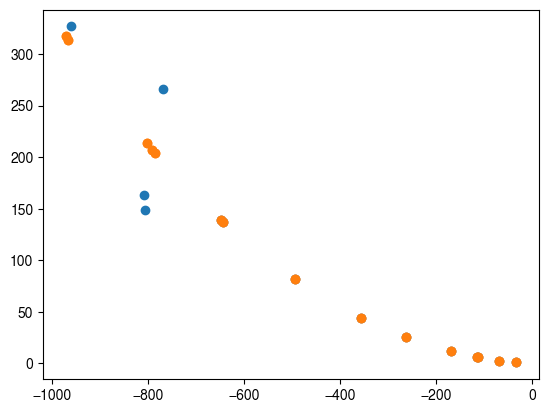

In [159]:
plt.scatter(this_track_hits.true_x, this_track_hits.true_y)
plt.scatter(majority_particle_hits.true_x, majority_particle_hits.true_y)

In [109]:
track_fitting_df_this_event

,track_id,nStates,nMeasurements,nOutliers,nHoles,nSharedHits,chi2Sum,NDF,nMajorityHits,majorityParticleId,...,cov_eQOP_eTHETA,cov_eQOP_eQOP,cov_eQOP_eT,cov_eT_eLOC0,cov_eT_eLOC1,cov_eT_ePHI,cov_eT_eTHETA,cov_eT_eQOP,cov_eT_eT,event_nr
208833,0,22,10,0,0,0,25.468483,27,10,653021945968788921,...,-7.405424e-10,0.000007,3.890566e-06,0.002989,-0.712618,-3.232941e-05,-0.000415,3.890566e-06,89.903625,127
208834,1,21,7,0,3,0,12.426776,18,5,585467951558230217,...,-2.207749e-10,0.000006,5.100535e-06,0.000045,0.010628,1.682924e-07,0.000045,5.100535e-06,124.836281,127
208835,2,23,11,0,0,0,20.687229,30,11,855683929200394344,...,2.415065e-09,0.000004,6.939135e-06,-0.000803,0.441222,5.318632e-05,0.000217,6.939135e-06,78.495171,127
208836,3,18,9,0,1,0,18.037138,24,9,311215666730500836,...,-3.145650e-09,0.000143,-3.743212e-04,0.000230,0.000549,-1.221683e-05,0.000015,-3.743212e-04,104.047142,127
208837,4,29,15,0,0,0,16.293671,33,15,121597189939069049,...,4.886871e-10,0.000004,-6.754619e-06,0.000074,-0.043019,-8.296975e-06,-0.000194,-6.754619e-06,89.236984,127
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
210476,1643,19,8,0,2,0,42.784981,22,8,653021945968722055,...,-1.551493e-10,0.000007,-2.609344e-05,0.001144,3.617592,1.333398e-04,0.000945,-2.609344e-05,107.648605,127
210477,1644,23,10,0,1,0,20.803616,24,10,288230376151711774,...,-4.278185e-11,0.000002,4.163128e-07,-0.002017,-0.842918,-1.639997e-05,-0.000690,4.163128e-07,156.804367,127
210478,1645,26,14,0,0,0,55.320282,29,14,414331165718085676,...,-9.352984e-09,0.000022,-3.920419e-05,0.000030,0.000845,-1.323789e-06,0.000021,-3.920419e-05,124.826744,127
210479,1646,26,11,0,2,0,42.056641,21,10,693554342615056412,...,9.014888e-09,0.000016,2.399143e-05,0.000406,-0.019744,-2.705614e-06,-0.000126,2.399143e-05,207.869247,127


In [209]:
particles_all = pd.concat(particles_frames, ignore_index=True)
particles_out = Path(particles_out_dir) / (
    f"{dataset_name_dot}.truth.particles.events{start_event}-{end_event}.h5"
)
logger.info(f"Writing particles to: {particles_out} (rows={len(particles_all)})")
write_particles_with_selection(particles_all, str(particles_out), columns_keep=particles_columns_keep)

2025-09-23 09:00:07,540 - INFO - utils.config - Writing particles to: h5_testing/v4/full_pileup_pilot/ttbar/v2/hdf5/truth/particles/full_pileup_pilot.ttbar.v2.truth.particles.events0-127.h5 (rows=6865870)


In [210]:
digihits_all = pd.concat(digihits_frames, ignore_index=True)
trkhits_out = Path(trkhits_out_dir) / (
    f"{dataset_name_dot}.reco.tracker_hits.events{start_event}-{end_event}.h5"
)
logger.info(f"Writing tracker hits to: {trkhits_out} (rows={len(digihits_all)})")
write_digihits_with_selection(digihits_all, str(trkhits_out), columns_keep=digihits_columns_keep)

2025-09-23 09:00:26,570 - INFO - utils.config - Writing tracker hits to: h5_testing/v4/full_pileup_pilot/ttbar/v2/hdf5/reco/tracker_hits/full_pileup_pilot.ttbar.v2.reco.tracker_hits.events0-127.h5 (rows=31623400)


In [211]:
tracks_all = pd.concat(tracks_frames, ignore_index=True)
tracks_out = Path(tracks_out_dir) / (
    f"{dataset_name_dot}.reco.tracks.events{start_event}-{end_event}.h5"
)
logger.info(f"Writing tracks to: {tracks_out} (rows={len(tracks_all)})")
write_tracks_with_selection(tracks_all, str(tracks_out), columns_keep=tracks_columns_keep)

2025-09-23 09:01:14,152 - INFO - utils.config - Writing tracks to: h5_testing/v4/full_pileup_pilot/ttbar/v2/hdf5/reco/tracks/full_pileup_pilot.ttbar.v2.reco.tracks.events0-127.h5 (rows=110727)
2025-09-23 09:01:14,156 - DEBUG - utils.track_utils - write_tracks_with_selection file=h5_testing/v4/full_pileup_pilot/ttbar/v2/hdf5/reco/tracks/full_pileup_pilot.ttbar.v2.reco.tracks.events0-127.h5 input_rows=110727 output_rows=110727 cols=['event_id', 'majority_particle_id', 'd0', 'z0', 'phi', 'theta', 'qop', 'hit_ids', 'track_id'] time=0.003s
2025-09-23 09:01:14,189 - DEBUG - utils.track_utils - Wrote event=0 tracks rows=855 nnz=10669 time=0.011s
2025-09-23 09:01:14,196 - DEBUG - utils.track_utils - Wrote event=1 tracks rows=912 nnz=11446 time=0.007s
2025-09-23 09:01:14,204 - DEBUG - utils.track_utils - Wrote event=2 tracks rows=939 nnz=11709 time=0.007s
2025-09-23 09:01:14,211 - DEBUG - utils.track_utils - Wrote event=3 tracks rows=863 nnz=10772 time=0.007s
2025-09-23 09:01:14,217 - DEBUG - u

## Check track hits truth

In [ ]:
base_path = Path("/pscratch/sd/d/danieltm/ColliderML/simulation/full_pileup_pilot/ttbar/v2/runs/0")
edm4hep_path = base_path / "edm4hep.root"
simhits_path = base_path / "simhits.root"
measurements_path = base_path / "measurements.root"
particles_path = base_path / "particles.root"

# Load edm4hep event
event = EDM4hepEvent(str(edm4hep_path), event_index=0)
# Get tracker hits
tracker_hits = event.get_tracker_hits_df()
# Get particles
particles_df = event.get_particles_df()

In [ ]:
# Load simhits
simhits = load_root_file(str(simhits_path), event_id=0, included_columns=["event_id", "particle_id", "tx", "ty", "tz"])

In [ ]:
# Load measurements
measurements = load_root_file(str(measurements_path), event_id=0, included_columns=["event_id", "particle_id", "true_x", "true_y", "true_z"])

In [ ]:
# Load particles
particles = load_root_file(str(particles_path), event_id=0, included_columns=["event_id", "particle_id", "px", "py", "pz", "vx", "vy", "vz"])

In [ ]:
tracks_csv = pd.read_csv(base_path / "event000000000-tracks_ckf.csv")

In [ ]:
simhits.columns

Index(['event_id', 'particle_id', 'tx', 'ty', 'tz'], dtype='object')

In [ ]:
measurements.columns

Index(['true_x', 'true_y', 'true_z'], dtype='object')

In [ ]:
simhits

,event_id,particle_id,tx,ty,tz
entry,,,,,
0,0,193663580070084651,85.631775,3.625161,-1515.599976
1,0,761108337025679422,92.851669,-3.027657,-1515.599976
2,0,834744829761229871,66.317802,-7.857886,-1515.599976
3,0,261320928573718739,65.890350,-3.451361,-1515.599976
4,0,639627695319286115,92.188545,-4.542456,-1515.599976
...,...,...,...,...,...
240617,0,869194728082571378,421.881561,942.290344,3009.500000
240618,0,653021945968854818,306.645935,886.782227,3009.500000
240619,0,428042075716911252,331.738159,868.459473,3009.500000


In [ ]:
measurements

,true_x,true_y,true_z
entry,,,
0,85.631775,3.625161,-1515.599976
1,92.851669,-3.027657,-1515.599976
2,66.317802,-7.857886,-1515.599976
3,65.890350,-3.451361,-1515.599976
4,92.188545,-4.542456,-1515.599976
...,...,...,...
240609,421.881561,942.290344,3009.500000
240610,306.645935,886.782227,3009.500000
240611,331.738159,868.459473,3009.500000


In [ ]:
def convert_hit_ids(hit_ids_str: str) -> np.ndarray:
    hit_ids_str = hit_ids_str.strip('[]').split(',')
    result = np.array([int(x) for x in hit_ids_str if x.strip()], dtype=np.int32)
    return result

def get_majority_barcode(hit_ids, simhits_root_df):
    track_hits = simhits_root_df.iloc[convert_hit_ids(hit_ids)]
    # Get the majority barcode
    majority_barcode = track_hits.particle_id.mode()[0]
    return majority_barcode

def get_majority_count(hit_ids, simhits_root_df):
    track_hits = simhits_root_df.iloc[convert_hit_ids(hit_ids)]
    majority_count = track_hits.particle_id.value_counts().max()
    return majority_count

tracks_csv["majority_barcode"] = tracks_csv.Measurements_ID.apply(get_majority_barcode, simhits_root_df=simhits)
tracks_csv["majority_count"] = tracks_csv.Measurements_ID.apply(get_majority_count, simhits_root_df=simhits)
tracks_csv

,track_id,seed_id,particleId,nStates,nMajorityHits,nMeasurements,nOutliers,nHoles,nSharedHits,chi2,ndf,chi2/ndf,pT,eta,phi,truthMatchProbability,good/duplicate/fake,Measurements_ID,majority_barcode,majority_count
0,6527,554834,vp=138|vs=0|p=0|g=1|sp=389,26,10,10,0,2,0,18.61120,25,0.744449,2.01273,-2.559940,3.111560,1.000000,duplicate,"[37285,41817,22621,19462,12808,112083,108482,1...",621496748577194373,10
1,6498,550795,vp=139|vs=0|p=0|g=1|sp=1198,25,9,9,0,1,0,47.51460,22,2.159750,1.37208,-2.384340,3.137390,1.000000,duplicate,"[37199,41692,22619,19434,112067,108474,106200,...",626000348204565678,9
2,6497,550786,vp=139|vs=0|p=0|g=1|sp=1198,25,10,10,0,0,0,44.34840,25,1.773930,1.37233,-2.384430,3.137190,1.000000,good,"[37199,41692,22619,19434,16141,112067,108474,1...",626000348204565678,10
3,6494,550724,vp=156|vs=0|p=0|g=0|sp=176,21,6,7,1,2,0,7.79184,17,0.458343,2.38555,0.571278,3.104690,0.857143,good,"[37460,42011,55441,66754,123965,140597,164963,...",702561541869797552,5
4,6489,550303,vp=136|vs=0|p=0|g=1|sp=21,25,12,12,0,1,0,13.95670,24,0.581530,1.53996,0.396739,-3.128060,1.000000,duplicate,"[37742,42062,55478,66527,123979,140387,153598,...",612489549322453013,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3582,4077,350136,vp=194|vs=0|p=0|g=0|sp=86,30,10,12,0,3,0,25.05900,19,1.318900,1.74707,1.850270,0.904130,0.833333,duplicate,"[31578,133281,148481,171303,175269,178768,2343...",873698327709876310,2
3583,4078,350140,vp=194|vs=0|p=0|g=0|sp=86,30,10,12,0,3,0,25.29090,19,1.331100,1.74626,1.851190,0.904297,0.833333,duplicate,"[31663,133281,148481,171303,175269,178768,2343...",873698327709876310,2
3584,4079,350215,vp=160|vs=0|p=0|g=0|sp=116,21,8,8,1,0,0,17.34420,18,0.963565,1.16056,-1.738000,0.817770,1.000000,good,"[31413,49048,61669,133799,148825,117506,114158...",720575940379279476,7
3585,4080,350230,vp=178|vs=0|p=0|g=1|sp=114,26,13,13,0,0,0,25.83320,26,0.993586,1.10782,-1.432900,0.872837,1.000000,good,"[31647,49102,61743,62630,133435,148507,148247,...",801640733672013938,6


In [ ]:
tracks_csv[["nMajorityHits", "majority_count"]]

,nMajorityHits,majority_count
0,10,10
1,9,9
2,10,10
3,6,5
4,12,5
...,...,...
3582,10,2
3583,10,2
3584,8,7
3585,13,6


In [ ]:
tracks_csv["majority_barcode"] = tracks_csv.Measurements_ID.apply(get_majority_barcode, simhits_root_df=measurements)
tracks_csv["majority_count"] = tracks_csv.Measurements_ID.apply(get_majority_count, simhits_root_df=measurements)
tracks_csv

,track_id,seed_id,particleId,nStates,nMajorityHits,nMeasurements,nOutliers,nHoles,nSharedHits,chi2,ndf,chi2/ndf,pT,eta,phi,truthMatchProbability,good/duplicate/fake,Measurements_ID,majority_barcode,majority_count
0,6527,554834,vp=138|vs=0|p=0|g=1|sp=389,26,10,10,0,2,0,18.61120,25,0.744449,2.01273,-2.559940,3.111560,1.000000,duplicate,"[37285,41817,22621,19462,12808,112083,108482,1...",621496748577194373,10
1,6498,550795,vp=139|vs=0|p=0|g=1|sp=1198,25,9,9,0,1,0,47.51460,22,2.159750,1.37208,-2.384340,3.137390,1.000000,duplicate,"[37199,41692,22619,19434,112067,108474,106200,...",626000348204565678,9
2,6497,550786,vp=139|vs=0|p=0|g=1|sp=1198,25,10,10,0,0,0,44.34840,25,1.773930,1.37233,-2.384430,3.137190,1.000000,good,"[37199,41692,22619,19434,16141,112067,108474,1...",626000348204565678,10
3,6494,550724,vp=156|vs=0|p=0|g=0|sp=176,21,6,7,1,2,0,7.79184,17,0.458343,2.38555,0.571278,3.104690,0.857143,good,"[37460,42011,55441,66754,123965,140597,164963,...",702561541869797552,6
4,6489,550303,vp=136|vs=0|p=0|g=1|sp=21,25,12,12,0,1,0,13.95670,24,0.581530,1.53996,0.396739,-3.128060,1.000000,duplicate,"[37742,42062,55478,66527,123979,140387,153598,...",612489549322453013,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3582,4077,350136,vp=194|vs=0|p=0|g=0|sp=86,30,10,12,0,3,0,25.05900,19,1.318900,1.74707,1.850270,0.904130,0.833333,duplicate,"[31578,133281,148481,171303,175269,178768,2343...",873698327709876310,10
3583,4078,350140,vp=194|vs=0|p=0|g=0|sp=86,30,10,12,0,3,0,25.29090,19,1.331100,1.74626,1.851190,0.904297,0.833333,duplicate,"[31663,133281,148481,171303,175269,178768,2343...",873698327709876310,10
3584,4079,350215,vp=160|vs=0|p=0|g=0|sp=116,21,8,8,1,0,0,17.34420,18,0.963565,1.16056,-1.738000,0.817770,1.000000,good,"[31413,49048,61669,133799,148825,117506,114158...",720575940379279476,8
3585,4080,350230,vp=178|vs=0|p=0|g=1|sp=114,26,13,13,0,0,0,25.83320,26,0.993586,1.10782,-1.432900,0.872837,1.000000,good,"[31647,49102,61743,62630,133435,148507,148247,...",801640733672013938,13


In [ ]:
tracks_csv[["nMajorityHits", "majority_count"]]

,nMajorityHits,majority_count
0,10,10
1,9,9
2,10,10
3,6,6
4,12,12
...,...,...
3582,10,10
3583,10,10
3584,8,8
3585,13,13


In [ ]:
measurements["particle_id"] = measurements.merge(simhits[["particle_id", "tx", "ty", "tz"]], left_on=["true_x", "true_y", "true_z"], right_on=["tx", "ty", "tz"], how="left").particle_id

In [ ]:
# Merge all_particles_df with measurements value counts
all_particles_df["num_hits"] = all_particles_df.particle_barcode.map(measurements.particle_id.value_counts())

In [ ]:
all_particles_df.energy.describe()

count    840822.000000
mean          5.620686
std         113.113587
min           0.000002
25%           0.004093
50%           0.015933
75%           0.158609
max        7000.000000
Name: energy, dtype: float64

2025-09-12 04:41:50,457 - DEBUG - matplotlib.colorbar - locator: <matplotlib.ticker.AutoLocator object at 0x7fab258e1090>


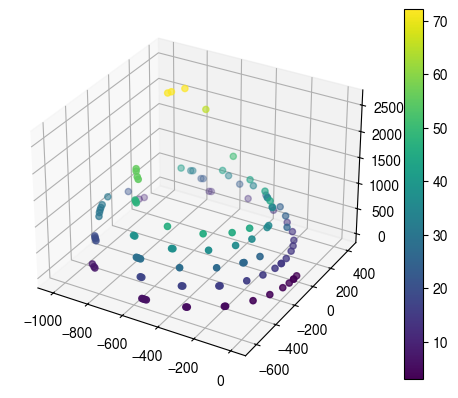

In [ ]:
multi_hits = tracker_hits[tracker_hits.particle_id == 34089]
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(multi_hits.x, multi_hits.y, multi_hits.z, c=multi_hits.time, cmap="viridis")
plt.colorbar(scatter)

## Testing h5 outputs

In [88]:
import pandas as pd
import h5py

def load_all_particles(h5_path, event_id=None):
    """
    Load particles data from HDF5 file.
    
    Args:
        h5_path: Path to HDF5 file
        event_id: Optional specific event ID to load. If None, loads all events.
    
    Returns:
        DataFrame with particles data
    """
    with h5py.File(h5_path, 'r') as f:
        frames = []
        
        if event_id is not None:
            # Direct access for single event
            ev_name = f'event_{event_id}'
            if ev_name in f['events']:
                arr = f['events'][ev_name]['particles'][:]
                df = pd.DataFrame(arr)
                df['event_id'] = event_id
                return df
            else:
                return pd.DataFrame()
        else:
            # Load all events
            for ev_name in f['events'].keys():
                ev_id = int(ev_name.split('_')[1])
                arr = f['events'][ev_name]['particles'][:]
                df = pd.DataFrame(arr)
                df['event_id'] = ev_id
                frames.append(df)
            return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

def load_all_digihits(h5_path, event_id=None):
    """
    Load digihits data from HDF5 file.
    
    Args:
        h5_path: Path to HDF5 file
        event_id: Optional specific event ID to load. If None, loads all events.
    
    Returns:
        DataFrame with digihits data
    """
    with h5py.File(h5_path, 'r') as f:
        frames = []
        
        if event_id is not None:
            # Direct access for single event
            ev_name = f'event_{event_id}'
            if ev_name in f['events']:
                arr = f['events'][ev_name]['measurements'][:]
                df = pd.DataFrame(arr)
                df['event_id'] = event_id
                return df
            else:
                return pd.DataFrame()
        else:
            # Load all events
            for ev_name in f['events'].keys():
                ev_id = int(ev_name.split('_')[1])
                arr = f['events'][ev_name]['measurements'][:]
                df = pd.DataFrame(arr)
                df['event_id'] = ev_id
                frames.append(df)
            return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

def load_all_tracks(h5_path, event_id=None):
    """
    Load tracks data from HDF5 file.
    
    Args:
        h5_path: Path to HDF5 file
        event_id: Optional specific event ID to load. If None, loads all events.
    
    Returns:
        Tuple of (tracks_df, hits_df) where hits_df contains track hit associations
    """
    with h5py.File(h5_path, 'r') as f:
        events = f.get('events')
        if events is None:
            return pd.DataFrame(), None
            
        if event_id is not None:
            # Direct access for single event
            ev_name = f'event_{event_id}'
            if ev_name in events:
                ev = events[ev_name]
                if 'tracks' not in ev:
                    return pd.DataFrame(), None
                    
                # Load tracks
                arr = ev['tracks'][:]
                tracks_df = pd.DataFrame(arr)
                tracks_df['event_id'] = event_id
                
                # Load hit associations
                if 'hit_ids_data' in ev and 'hit_ids_indptr' in ev:
                    data = ev['hit_ids_data'][:]
                    indptr = ev['hit_ids_indptr'][:]
                    if indptr is not None and len(indptr) >= 1:
                        hit_lists = [data[indptr[i]:indptr[i+1]] for i in range(len(indptr) - 1)]
                        hits_df = pd.DataFrame({
                            'event_id': event_id,
                            'track_id': tracks_df['track_id'].reset_index(drop=True),
                            'hit_ids': hit_lists
                        })
                        return tracks_df, hits_df
                    else:
                        return tracks_df, None
                else:
                    logger.warning(f"Missing hit_ids for event {ev_name}")
                    return tracks_df, None
            else:
                return pd.DataFrame(), None
        else:
            # Load all events
            frames = []
            hit_frames = []
            for ev_name in events.keys():
                ev = events[ev_name]
                try:
                    ev_id = int(ev_name.split('_')[1])
                except Exception:
                    continue
                # Tracks table
                if 'tracks' not in ev:
                    continue
                arr = ev['tracks'][:]
                df = pd.DataFrame(arr)
                df['event_id'] = ev_id
                frames.append(df)

                # Reconstruct hit_ids from CSR or fall back to legacy vlen
                if 'hit_ids_data' in ev and 'hit_ids_indptr' in ev:
                    data = ev['hit_ids_data'][:]
                    indptr = ev['hit_ids_indptr'][:]
                    if indptr is not None and len(indptr) >= 1:
                        hit_lists = [data[indptr[i]:indptr[i+1]] for i in range(len(indptr) - 1)]
                    else:
                        hit_lists = []
                    hit_df = pd.DataFrame({
                        'event_id': ev_id,
                        'track_id': df['track_id'].reset_index(drop=True),
                        'hit_ids': hit_lists
                    })
                    hit_frames.append(hit_df)
                else:
                    logger.warning(f"Missing hit_ids for event {ev_name}")
            tracks_df = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()
            if hit_frames:
                hits_df = pd.concat(hit_frames, ignore_index=True)
                return tracks_df, hits_df
            else:
                return tracks_df, None

In [91]:
particles_file = "/global/cfs/cdirs/m4958/usr/danieltm/ColliderML/software/colliderml_dev/notebooks/infrastructure/h5_testing/v4/full_pileup_pilot/ttbar/v2/hdf5/truth/particles/full_pileup_pilot.ttbar.v2.truth.particles.events128-255.h5"
digihits_file = "/global/cfs/cdirs/m4958/usr/danieltm/ColliderML/software/colliderml_dev/notebooks/infrastructure/h5_testing/v4/full_pileup_pilot/ttbar/v2/hdf5/reco/tracker_hits/full_pileup_pilot.ttbar.v2.reco.tracker_hits.events128-255.h5"
tracks_file = "/global/cfs/cdirs/m4958/usr/danieltm/ColliderML/software/colliderml_dev/notebooks/infrastructure/h5_testing/v4/full_pileup_pilot/ttbar/v2/hdf5/reco/tracks/full_pileup_pilot.ttbar.v2.reco.tracks.events128-255.h5"

In [101]:
particles_df = load_all_particles(particles_file, event_id = 127)
digihits_df = load_all_digihits(digihits_file, event_id = 255)
tracks_df, track_hits_df = load_all_tracks(tracks_file, event_id = 255)

In [102]:
digihits_df

,x,y,z,time,particle_id,true_x,true_y,true_z,volume_id,layer_id,surface_id,cell_id,detector,event_id
0,82.169853,10.182592,-1515.599976,2.698382,806920,82.186806,10.184404,-1515.599976,16,4,1,65296924775,1,255
1,60.414680,6.768027,-1515.599976,2.118049,63519,60.419945,6.780114,-1515.599976,16,4,1,66437775463,1,255
2,77.112015,-3.876668,-1515.599976,16.312775,683971,77.120255,-3.855591,-1515.599976,16,4,1,1291845735,1,255
3,50.362980,8.860623,-1515.599976,9.094869,50886,50.356552,8.873676,-1515.599976,16,4,1,65749909607,1,255
4,47.158176,-7.208955,-1515.599976,10.204144,26706,47.140148,-7.212642,-1515.599976,16,4,1,2415919207,1,255
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
489463,330.051819,933.722046,3009.500000,8.249406,5450,315.001068,895.574219,3009.500000,30,12,192,16088948576606,5,255
489464,430.297180,894.528931,3009.500000,9.694159,12764,428.786835,890.754700,3009.500000,30,12,192,1580549050718,5,255
489465,384.455109,912.451904,3009.500000,15.252088,381612,408.426514,973.827332,3009.500000,30,12,192,171799777630,5,255
489466,387.188965,911.382996,3009.500000,15.265630,381612,411.076752,972.584351,3009.425781,30,12,192,249109188958,5,255


In [103]:
particles_df.shape

(53163, 17)

In [104]:
particles_df

,particle_id,pdg_id,mass,energy,charge,vx,vy,vz,time,px,py,pz,num_tracker_hits,num_calo_hits,vertex_primary,parent_id,event_id
0,62,-211,0.139570,4.967253,-1.0,0.001510,-0.001585,-62.713993,-1.300332,-0.044169,-0.554913,4.933989,10,0,1,8.0,127
1,71,-211,0.139570,108.627262,-1.0,0.001510,-0.001585,-62.713993,-1.300332,-2.821236,1.556158,108.579376,1,0,1,8.0,127
2,174,321,0.493680,44.037358,1.0,0.001510,-0.001585,-62.713993,-1.300332,-0.938482,-4.698259,43.773174,11,0,1,10.0,127
3,175,-321,0.493680,50.286039,-1.0,0.001510,-0.001585,-62.713993,-1.300332,-1.984151,-4.650297,50.028790,15,0,1,10.0,127
4,176,321,0.493680,27.395853,1.0,0.001510,-0.001585,-62.713993,-1.300332,0.281140,-2.662016,27.260294,12,0,1,10.0,127
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53158,923111,11,0.000511,0.001793,-1.0,-616.884583,-724.098022,3005.035400,11.466586,0.000604,0.000780,-0.001407,2,0,1,923110.0,127
53159,923112,11,0.000511,0.000697,-1.0,-602.013977,-727.439209,3004.541748,11.517452,0.000330,0.000127,-0.000315,1,0,1,922981.0,127
53160,925092,11,0.000511,0.000535,-1.0,-589.290039,-778.887756,2604.589600,13.504222,0.000113,-0.000061,-0.000094,1,0,1,924883.0,127
53161,926292,11,0.000511,0.000584,-1.0,-152.796890,-737.303223,2590.416016,14.728901,-0.000059,0.000102,-0.000257,1,0,1,366.0,127


In [137]:
track_hits_df.iloc[2]

event_id                                                  255
track_id                                                 1635
hit_ids     [38154, 42663, 56390, 75880, 75896, 79176, 126...
Name: 2, dtype: object

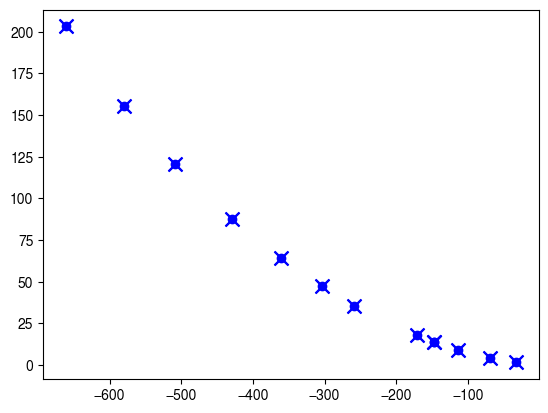

In [145]:
track_index = 2
track_hit_ids = track_hits_df.iloc[track_index].hit_ids

plt.scatter(digihits_df.x.iloc[track_hit_ids], digihits_df.y.iloc[track_hit_ids], marker='o', color="b")

# Get the majority particle id for the track
track_majority_particle_id = tracks_df.iloc[track_index]['majority_particle_id']

# Get the hit ids for the majority particle id
majority_particle_hit_ids = digihits_df[digihits_df.particle_id == track_majority_particle_id].index.tolist()
plt.scatter(digihits_df.x.iloc[majority_particle_hit_ids], digihits_df.y.iloc[majority_particle_hit_ids], marker='x', color="b", s=100)

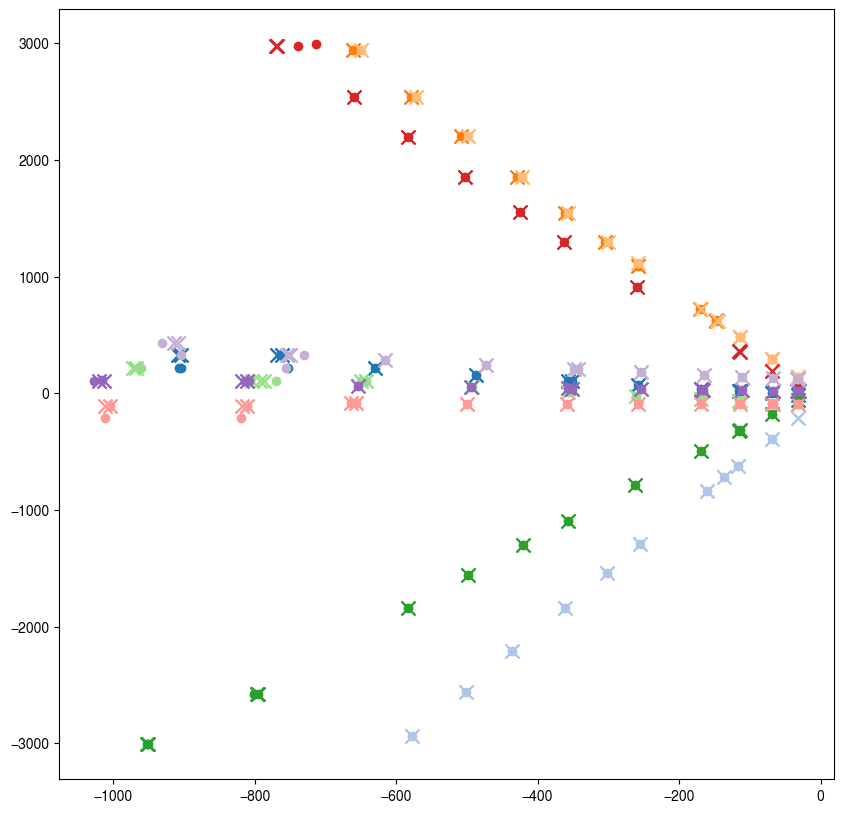

In [161]:
plt.figure(figsize=(10, 10))

num_tracks_to_sample = 10

# Define a list of colors to use for each track/particle pair
# Use tab20 colormap and cycle through it for more colors
cmap = plt.cm.tab20
colors = [cmap(i % 20) for i in range(num_tracks_to_sample)]

for i in range(num_tracks_to_sample):
    track_hit_ids = track_hits_df.iloc[i].hit_ids

    # Use the same color for both track hits and particle hits
    color = colors[i]
    
    plt.scatter(digihits_df.x.iloc[track_hit_ids], digihits_df.z.iloc[track_hit_ids], marker='o', color=color)

    # Get the majority particle id for the track
    track_majority_particle_id = tracks_df.iloc[i]['majority_particle_id']

    # Get the hit ids for the majority particle id
    majority_particle_hit_ids = digihits_df[digihits_df.particle_id == track_majority_particle_id].index.tolist()
    plt.scatter(digihits_df.x.iloc[majority_particle_hit_ids], digihits_df.z.iloc[majority_particle_hit_ids], marker='x', color=color, s=100)

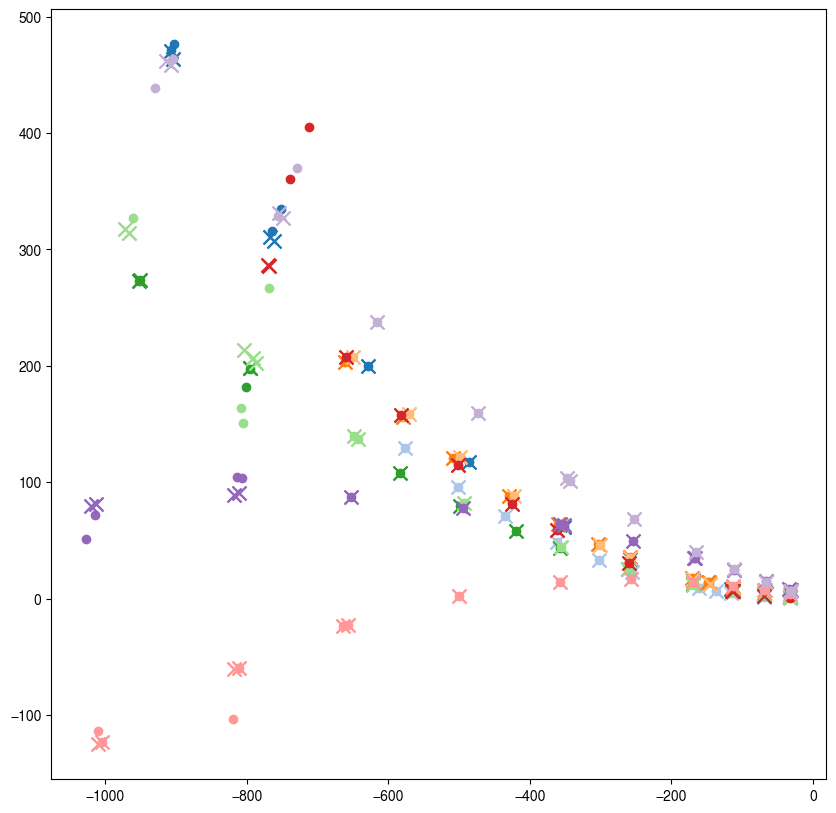

In [162]:
plt.figure(figsize=(10, 10))

num_tracks_to_sample = 10

# Define a list of colors to use for each track/particle pair
# Use tab20 colormap and cycle through it for more colors
cmap = plt.cm.tab20
colors = [cmap(i % 20) for i in range(num_tracks_to_sample)]

for i in range(num_tracks_to_sample):
    track_hit_ids = track_hits_df.iloc[i].hit_ids

    # Use the same color for both track hits and particle hits
    color = colors[i]
    
    plt.scatter(digihits_df.x.iloc[track_hit_ids], digihits_df.y.iloc[track_hit_ids], marker='o', color=color)

    # Get the majority particle id for the track
    track_majority_particle_id = tracks_df.iloc[i]['majority_particle_id']

    # Get the hit ids for the majority particle id
    majority_particle_hit_ids = digihits_df[digihits_df.particle_id == track_majority_particle_id].index.tolist()
    plt.scatter(digihits_df.x.iloc[majority_particle_hit_ids], digihits_df.y.iloc[majority_particle_hit_ids], marker='x', color=color, s=100)

In [ ]:
plt.figure(figsize=(10, 10))

num_tracks_to_sample = 10

# Define a list of colors to use for each track/particle pair
# Use tab20 colormap and cycle through it for more colors
cmap = plt.cm.tab20
colors = [cmap(i % 20) for i in range(num_tracks_to_sample)]

for i in range(num_tracks_to_sample):
    track_hit_ids = track_hits_df.iloc[i].hit_ids

    # Use the same color for both track hits and particle hits
    color = colors[i]
    
    plt.scatter(digihits_df.x.iloc[track_hit_ids], digihits_df.y.iloc[track_hit_ids], marker='o', color=color)

    # Get the majority particle id for the track
    track_majority_particle_id = tracks_df.iloc[i]['majority_particle_id']

    # Get the hit ids for the majority particle id
    majority_particle_hit_ids = digihits_df[digihits_df.particle_id == track_majority_particle_id].index.tolist()
    plt.scatter(digihits_df.x.iloc[majority_particle_hit_ids], digihits_df.y.iloc[majority_particle_hit_ids], marker='x', color=color, s=100)

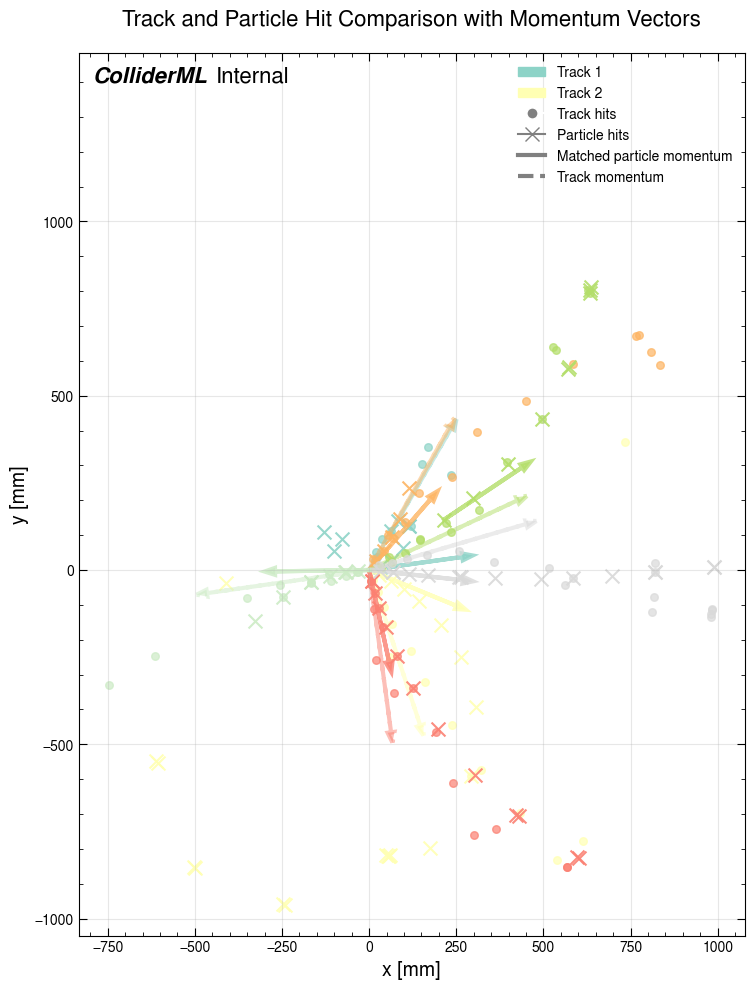

In [40]:
import matplotlib.patches as mpatches

plt.figure(figsize=(10, 10))
num_tracks_to_sample = 7

# Randomly sample track indices
track_indices = np.random.choice(len(tracks_df), size=min(num_tracks_to_sample, len(tracks_df)), replace=False)

# Use a pleasant colormap with more colors
cmap = plt.cm.Set3  # Set3 provides 12 distinct, pleasant colors
colors = [cmap(i / num_tracks_to_sample) for i in range(num_tracks_to_sample)]

legend_elements = []

for idx, track_idx in enumerate(track_indices):
    # Plot the track hits
    track_hit_ids = track_hits_df.iloc[track_idx].hit_ids
    track_scatter = plt.scatter(digihits_df.x.iloc[track_hit_ids], digihits_df.y.iloc[track_hit_ids], 
                               marker='o', color=colors[idx], s=30, alpha=0.7, 
                               label=f'Track {idx+1} hits')

    # Get the majority particle id for the track
    majority_particle_id = tracks_df.iloc[track_idx]['majority_particle_id']

    # Get the hit ids for the majority particle id
    majority_particle_hit_ids = digihits_df[digihits_df.particle_id == majority_particle_id].index.tolist()
    particle_scatter = plt.scatter(digihits_df.x.iloc[majority_particle_hit_ids], digihits_df.y.iloc[majority_particle_hit_ids], 
                                  marker='x', color=colors[idx], s=100, alpha=0.9,
                                  label=f'Particle {idx+1} hits')
    
    # Plot the phi vector of the particle as an arrow (solid arrow)
    particle_entry = particles_df[particles_df['particle_id'] == majority_particle_id].iloc[0]
    normalised_momentum_vector = particle_entry[['px', 'py']].values / np.linalg.norm(particle_entry[['px', 'py']].values)*300
    particle_arrow = plt.arrow(particle_entry['vx'], particle_entry['vy'], normalised_momentum_vector[0], normalised_momentum_vector[1], 
              color=colors[idx], head_width=20, head_length=30, length_includes_head=True, alpha=0.8, linewidth=3)
    phi = np.arctan2(particle_entry['py'], particle_entry['px'])

    # Plot the phi vector of the track (dashed arrow)
    track_entry = tracks_df.iloc[track_idx]
    phi = track_entry['phi']
    
    # Convert phi to px, py components (assuming unit momentum for visualization)
    track_px = np.cos(phi) * 500  # scale for visualization
    track_py = np.sin(phi) * 500
    
    # Plot from origin (assuming tracks start from origin for visualization)
    track_arrow = plt.arrow(0, 0, track_px, track_py, color=colors[idx], head_width=20, head_length=30, 
              length_includes_head=True, alpha=0.5, linewidth=3, linestyle='--')

# Create custom legend elements
legend_elements = [
    mpatches.Patch(color=colors[0], label='Track 1'),
    mpatches.Patch(color=colors[1], label='Track 2'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markersize=8, label='Track hits'),
    plt.Line2D([0], [0], marker='x', color='gray', markerfacecolor='gray', markersize=10, label='Particle hits'),
    plt.Line2D([0], [0], color='gray', linewidth=3, label='Matched particle momentum'),
    plt.Line2D([0], [0], color='gray', linewidth=3, linestyle='--', label='Track momentum')
]

plt.legend(handles=legend_elements, loc='upper right', frameon=True, fancybox=True, shadow=True)

plt.xlabel('x [mm]', fontsize=14)
plt.ylabel('y [mm]', fontsize=14)
plt.title('Track and Particle Hit Comparison with Momentum Vectors', fontsize=16, pad=20)

# Add ATLAS label
atl.atlasify("Internal")

plt.grid(True, alpha=0.3)
plt.gca().set_aspect('equal', 'box')
plt.tight_layout()
plt.show()
